# Getting started with Dataset

In [1]:
import numpy as np
import IPython
import matplotlib.pyplot as plt
import torch
import torchaudio

import megamicros
from megamicros.log import log
from megamicros.ailab.dataset import AidbDataset, AidbTimeStrechingTransform

log.setLevel( "WARNING" )
#log.setLevel( "INFO" )
print( f"megamicros-{megamicros.__version__}" )


megamicros-2.0.53


In [9]:
print( AidbDataset.__init__.__doc__ )


        Get meta informations from the remote database. 
        If download is True, all sammples are downloaded from the database and saved in a local directory as wav files.
        Either samples and labels can be transformed by giving a `transform` and/or `target_transform` callback as argument.
        If `sample_duration` is given, samples are cut (and/or stretched wether the `time_stretching` argument is provided or not) to fit the given duration.
        In that case, samples that are more than several times longer than the requested duration are split.  
        A json index file is created which name is given by the `DATASET_CONFIG_NAME` constant

        Parameters
        ----------
        root: str|Path
            Path to the directory where the dataset is found or downloaded.
        dbhost: str
            hostname or IP address
        login: str, optionnal
            database acces login
        email: str, optionnal
            database user email
        passwd:

In [2]:
# Plot spectrogram

def plot_specgram(waveform, sample_rate, title="Spectrogram"):
    waveform = waveform.numpy()

    figure, ax = plt.subplots()
    ax.specgram(waveform[0], Fs=sample_rate)
    figure.suptitle(title)
    figure.tight_layout()

In [3]:
# Set database access credentials
DBHOST = 'http://dbwelfare.bimea.tech/'
#DBHOST = 'http://dbchantier.bimea.tech/'
LOGIN = 'ailab'
EMAIL = 'bruno.gas@biimea.com'
PASSWORD = '#T;uZnQ5UJ_JC~&'

DATASET = 'test0'

split_size = 2.0
audio_transforms = torch.nn.Sequential(
    #torchaudio.transforms.MelSpectrogram(sample_rate=10000, n_mels=128),
    torchaudio.transforms.Spectrogram( n_fft=400, win_length=400, hop_length=160, pad=0, power=2, normalized=False ),
    AidbTimeStrechingTransform( factor=0.5, output_length=int( split_size*10000 ) ),
    #torchaudio.transforms.FrequencyMasking(freq_mask_param=15),
    #torchaudio.transforms.TimeMasking(time_mask_param=35)
)

#dataset = AidbDataset( '/Users/brunogas/Data/dataset/assets', DBHOST, DATASET, channels=[1,], split_size=split_size, zero_padding=True, transform=audio_transforms )
dataset = AidbDataset( '/Users/brunogas/Data/dataset/assets', DBHOST, DATASET, channels=[1,], split_size=split_size, zero_padding=True )

print( f"Number of extracted samples in database: {len( dataset )}" )

# extract data and print their shape
#for data_idx, [data, sample_rate, label] in enumerate( dataset ):
#    print( f"Extracted [{data_idx}] signal (label:{label}, sr={sample_rate}) of shape: {np.shape( data )}" )

0%
0%
0%
0%
20%
20%
20%
40%
40%
40%
60%
60%
60%
80%
80%
80%
Number of extracted samples in database: 307


In [ ]:
import os
import torchaudio
_SAMPLE_DIR = "_assets"
YESNO_DATASET_PATH = os.path.join(_SAMPLE_DIR, "yes_no")
os.makedirs(YESNO_DATASET_PATH, exist_ok=True)

dataset = torchaudio.datasets.YESNO(YESNO_DATASET_PATH, download=True )

In [ ]:
i = 2
waveform, label = dataset[i]
print( f"wavform tensor shape: {waveform.shape} (datatype: {waveform.dtype}, device:{waveform.device})" )
print( f"label: {label}")

sample_rate = dataset.sample_rate
plot_specgram( waveform, sample_rate, title=f"Sample {i}: {label}" )
IPython.display.Audio(waveform, rate=sample_rate)


## Preparing data for training with DataLoaders

In [4]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=5, shuffle=True)

## Iterate through the DataLoader

data.shape=(20000,)
 .samples_witdh: 20000
data.shape=(20000,)
 .samples_witdh: 20000
data.shape=(20000,)
 .samples_witdh: 20000
data.shape=(20000,)
 .samples_witdh: 20000
data.shape=(20000,)
 .samples_witdh: 20000
Feature batch shape: torch.Size([5, 1, 20000])
First sample label is: 30
labels are: tensor([30, 30, 30, 30, 30])
features are: tensor([[[ 3.2196e-03,  1.0111e-02, -1.2328e-02,  ...,  1.3097e-02,
          -3.4081e-03,  0.0000e+00]],

        [[ 1.8096e-04,  3.5438e-04, -5.9566e-04,  ..., -2.8501e-03,
          -7.4646e-04,  0.0000e+00]],

        [[ 4.1847e-03, -5.5796e-04, -2.3751e-03,  ..., -3.2120e-03,
          -3.4458e-03,  0.0000e+00]],

        [[ 9.1234e-04,  3.6946e-04,  7.5400e-06,  ..., -4.3279e-03,
          -1.6437e-03,  0.0000e+00]],

        [[ 2.7445e-03,  1.4778e-03, -1.7644e-03,  ..., -3.9208e-03,
          -1.5759e-03,  0.0000e+00]]])


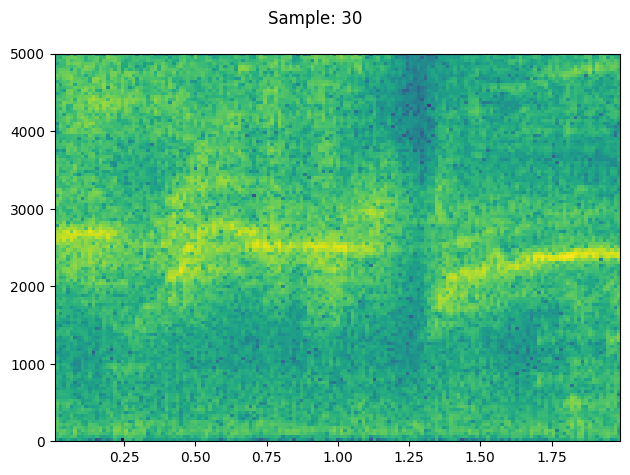

In [10]:
features, labels = next(iter( dataloader ) )
print(f"Feature batch shape: {features.size()}")
print(f"First sample label is: {labels[0]}")
print( f"labels are: {labels}" )
print( f"features are: {features}" )

sample_rate = dataset.sample_rate
plot_specgram( features[0], sample_rate, title=f"Sample: {labels[0]}" )
IPython.display.Audio(features[0], rate=sample_rate)
